# exp-cv-audit-01 — CV 강건성 감사

## 목적
현재 random Stratified CV OOF가 유사 mutation profile의 cross-fold 혼입으로 낙관적인지 점검한다. 이는 점수 향상·제출 후보 선택 실험이 아니라, 이후 로컬 개선의 신뢰도를 판단하는 감사 실험이다.

### 고정 규칙
- `SEED=42`, 5-fold
- 기존 08-spec LR (`C=0.07`, `max_iter=2000`, balanced)
- 비교: StratifiedKFold vs StratifiedGroupKFold
- 그룹: train binary mutation profile의 exact duplicate + top-1 cosine similarity `>= 0.90`
- test.csv를 읽지 않음. fold-train-only feature/contrast 선택 유지.


In [1]:
from pathlib import Path
import subprocess, sys, json
import pandas as pd
import matplotlib.pyplot as plt

def find_exp_model():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct = path / 'common' / 'exp_cv_audit_runner.py'
        project = path / 'experiments' / 'gs' / 'notebooks' / 'exp_model' / 'common' / 'exp_cv_audit_runner.py'
        if direct.exists(): return path
        if project.exists(): return project.parent.parent
    raise FileNotFoundError('CV audit runner를 찾지 못했습니다.')

EXP_MODEL = find_exp_model()
RUNNER = EXP_MODEL / 'common' / 'exp_cv_audit_runner.py'
RESULT_DIR = EXP_MODEL / 'result'
RUN_ID = 'exp-cv-audit-01'
SEED = 42
RUN_EXPERIMENT = True
print({'runner': RUNNER, 'seed': SEED, 'profile_cosine_threshold': 0.90})


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model/common/exp_cv_audit_runner.py'), 'seed': 42, 'profile_cosine_threshold': 0.9}


In [2]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--seed', str(SEED), '--run-id', RUN_ID]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    assert process.stdout is not None
    tail = []
    for line in process.stdout:
        print(line, end='')
        tail = (tail + [line])[-80:]
    return_code = process.wait()
    if return_code:
        raise RuntimeError(f'CV audit runner failed (exit={return_code}). Last runner output:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 결과 집계만 수행합니다.')



row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 370.66it/s]

CV audit stratified_random: 100%|██████████| 5/5 [00:30<00:00,  6.04s/fold]

CV audit stratified_profile_group: 100%|██████████| 5/5 [00:30<00:00,  6.07s/fold]
{
  "summary": [
    {
      "cv_mode": "stratified_random",
      "seed": 42,
      "oof_macro_f1": 0.4825927951809337,
      "fold_macro_f1_mean": 0.48176231474053155,
      "fold_macro_f1_std": 0.014228029355998395,
      "feature_count_mean": 8175.2,
      "runtime_seconds": 30.196456167002907,
      "leakage_check": true,
      "nan_as_mutation_count": 0,
      "delta_vs_random_oof": 0.0
    },
    {
      "cv_mode": "stratified_profile_group",
      "seed": 42,
      "oof_macro_f1": 0.4836270532541717,
      "fold_macro_f1_mean": 0.48530660999548453,
      "fold_macro_f1_std": 0.008181489838263532,
      "feature_count_mean": 8168.2,
      "runtime_seconds": 31.01691495801788,
      "leakage_check": true,
      "nan_as_mutation_count": 0,
    

,cv_mode,seed,oof_macro_f1,fold_macro_f1_mean,fold_macro_f1_std,feature_count_mean,runtime_seconds,leakage_check,nan_as_mutation_count,delta_vs_random_oof
0,stratified_random,42,0.482593,0.481762,0.014228,8175.2,30.196456,True,0,0.000000
1,stratified_profile_group,42,0.483627,0.485307,0.008181,8168.2,31.016915,True,0,0.001034


,profile_cosine_threshold,exact_duplicate_rows,near_neighbour_pairs,n_groups,max_group_size,grouped_row_fraction
0,0.9,1031,939,5609,94,0.166586


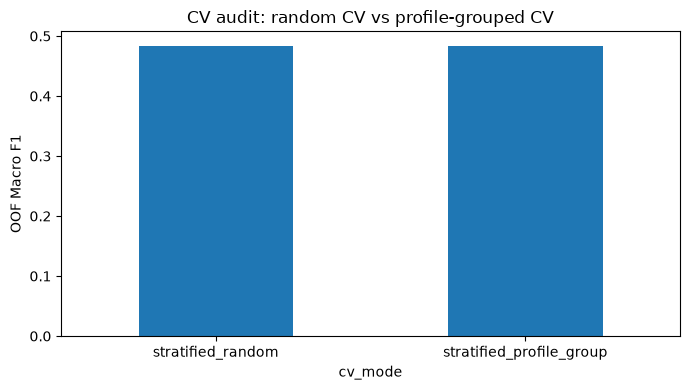

In [3]:
summary_path = RESULT_DIR / f'{RUN_ID}_seed{SEED}_summary.csv'
groups_path = RESULT_DIR / f'{RUN_ID}_seed{SEED}_groups.json'
summary = pd.read_csv(summary_path)
groups = json.loads(groups_path.read_text(encoding='utf-8'))
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
display(summary)
display(pd.DataFrame([groups]))
ax = summary.plot.bar(x='cv_mode', y='oof_macro_f1', legend=False, figsize=(7, 4), title='CV audit: random CV vs profile-grouped CV')
ax.set_ylabel('OOF Macro F1'); plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(RESULT_DIR / f'{RUN_ID}_seed{SEED}_cv_comparison.png', dpi=160)
plt.show()
